# Problem 1

<div style="text-align:center;">
    <img src="Problem1.png" width=600">
</div>

## Part 1
Construct the transformation matrices that describe the kinematics of the three center of mass positions
of the links.

In [52]:
import sympy as sp
from sympy import Matrix, cos, sin, simplify
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Time
t = sp.symbols('t', real=True)

# Configuration variables as a function of time
x = sp.Function('x')(t)
y = sp.Function('y')(t)
theta = sp.Function('theta')(t)
alpha1 = sp.Function('alpha1')(t)
alpha2 = sp.Function('alpha2')(t)

# Constants
L1, Lb, L2 = sp.symbols('L1 Lb L2', positive=True, real=True)

q = sp.Matrix([x, y, theta, alpha1, alpha2])
qd = q.diff(t)
qdd = q.diff(t, 2)

# Helper Functions 
def cross_matrix(vec):
    
    return np.array([[0, -vec[2,0], vec[1,0]],
                   [vec[2,0], 0, -vec[0,0]],
                   [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    
    return np.array([[mat[2,1]],
                   [mat[0,2]], 
                   [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    
    return m
    
def R_z(theta):
    return np.array([[cos(theta), -sin(theta), 0], 
                   [sin(theta),  cos(theta), 0],
                   [0,           0,          1]])

def R_y(theta):
    return np.array([[cos(theta), 0, sin(theta)], 
                   [0,          1, 0],
                   [-sin(theta),0, cos(theta)]])

def R_x(theta):
    return np.array([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta),  cos(theta)]])

def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m

# World to body center
T0b = T(R_z(theta), Matrix([[x], [y], [0]]))
T_0b = simplify(T0b)

# Left link COM transform
T_center_to_left_joint = T(Matrix.eye(3), Matrix([-Lb/2, 0, 0]))
T_left_joint_rotation  = T(R_z(alpha1), Matrix([0, 0, 0]))
T_left_link_com_offset = T(Matrix.eye(3), Matrix([-L1/2, 0, 0]))
T_01 = simplify(T_0b @ T_center_to_left_joint @ T_left_joint_rotation @ T_left_link_com_offset)

# Right link COM transform
T_center_to_right_joint = T(Matrix.eye(3), Matrix([Lb/2, 0, 0]))
T_right_joint_rotation  = T(R_z(alpha2), Matrix([0, 0, 0]))
T_right_link_com_offset = T(Matrix.eye(3), Matrix([L2/2, 0, 0]))
T_02 = simplify(T_0b @ T_center_to_right_joint @ T_right_joint_rotation @ T_right_link_com_offset)

print("World to body center transformation matrix:")
T_0b

World to body center transformation matrix:


Matrix([
[cos(theta(t)), -sin(theta(t)), 0, x(t)],
[sin(theta(t)),  cos(theta(t)), 0, y(t)],
[            0,              0, 1,    0],
[            0,              0, 0,    1]])

In [53]:
print("Left link COM transformation matrix:")
T_01

Left link COM transformation matrix:


Matrix([
[cos(alpha1(t) + theta(t)), -sin(alpha1(t) + theta(t)), 0, -L1*cos(alpha1(t) + theta(t))/2 - Lb*cos(theta(t))/2 + x(t)],
[sin(alpha1(t) + theta(t)),  cos(alpha1(t) + theta(t)), 0, -L1*sin(alpha1(t) + theta(t))/2 - Lb*sin(theta(t))/2 + y(t)],
[                        0,                          0, 1,                                                           0],
[                        0,                          0, 0,                                                           1]])

In [54]:
print("Right link COM transformation matrix:")
T_02

Right link COM transformation matrix:


Matrix([
[cos(alpha2(t) + theta(t)), -sin(alpha2(t) + theta(t)), 0, L2*cos(alpha2(t) + theta(t))/2 + Lb*cos(theta(t))/2 + x(t)],
[sin(alpha2(t) + theta(t)),  cos(alpha2(t) + theta(t)), 0, L2*sin(alpha2(t) + theta(t))/2 + Lb*sin(theta(t))/2 + y(t)],
[                        0,                          0, 1,                                                          0],
[                        0,                          0, 0,                                                          1]])

## Part 2
Generate the body twists for these link center of masses.

In [55]:
# Body twist matrices
Vb_hat_1 = simplify(T_01.inv() @ sp.diff(T_01, t))
Vb_hat_b = simplify(T_0b.inv() @ sp.diff(T_0b, t))
Vb_hat_2 = simplify(T_02.inv() @ sp.diff(T_02, t))

# Body twist vectors
Vb_1 = twist2vec(Vb_hat_1)
Vb_b = twist2vec(Vb_hat_b)
Vb_2 = twist2vec(Vb_hat_2)

Vb_b

Matrix([
[                                                                     0],
[                                                                     0],
[                                               Derivative(theta(t), t)],
[ sin(theta(t))*Derivative(y(t), t) + cos(theta(t))*Derivative(x(t), t)],
[-sin(theta(t))*Derivative(x(t), t) + cos(theta(t))*Derivative(y(t), t)],
[                                                                     0]])

In [56]:
Vb_1

Matrix([
[                                                                                                                                                                                                                                                                   0],
[                                                                                                                                                                                                                                                                   0],
[                                                                                                                                                                                                                  Derivative(alpha1(t), t) + Derivative(theta(t), t)],
[(-Lb*sin(2*alpha1(t) + theta(t))*Derivative(theta(t), t)/2 + Lb*sin(theta(t))*Derivative(theta(t), t)/2 + sin(2*alpha1(t) + 2*theta(t))*Derivative(y(t), t) + cos(2*alpha1(t) + 2*theta(t))*Derivative

In [57]:
Vb_2

Matrix([
[                                                                                                                                                                                                                                                                  0],
[                                                                                                                                                                                                                                                                  0],
[                                                                                                                                                                                                                 Derivative(alpha2(t), t) + Derivative(theta(t), t)],
[(Lb*sin(2*alpha2(t) + theta(t))*Derivative(theta(t), t)/2 - Lb*sin(theta(t))*Derivative(theta(t), t)/2 + sin(2*alpha2(t) + 2*theta(t))*Derivative(y(t), t) + cos(2*alpha2(t) + 2*theta(t))*Derivative(x(t

## Part 3
Generate the body body twist Jacobians that map pose/joint velocities into twists.

In [58]:
# Body Jacobians
Jb_1 = simplify(Vb_1.jacobian(qd))
Jb_b = simplify(Vb_b.jacobian(qd))
Jb_2 = simplify(Vb_2.jacobian(qd))

Jb_b

Matrix([
[             0,             0, 0, 0, 0],
[             0,             0, 0, 0, 0],
[             0,             0, 1, 0, 0],
[ cos(theta(t)), sin(theta(t)), 0, 0, 0],
[-sin(theta(t)), cos(theta(t)), 0, 0, 0],
[             0,             0, 0, 0, 0]])

In [59]:
Jb_1

Matrix([
[                                                                0,                                                           0,                           0,     0, 0],
[                                                                0,                                                           0,                           0,     0, 0],
[                                                                0,                                                           0,                           1,     1, 0],
[(cos(2*alpha1(t) + 2*theta(t)) + 1)/(2*cos(alpha1(t) + theta(t))), sin(2*alpha1(t) + 2*theta(t))/(2*cos(alpha1(t) + theta(t))),        -Lb*sin(alpha1(t))/2,     0, 0],
[                                       -sin(alpha1(t) + theta(t)),                                   cos(alpha1(t) + theta(t)), -L1/2 - Lb*cos(alpha1(t))/2, -L1/2, 0],
[                                                                0,                                                           0,                  

In [60]:
Jb_2

Matrix([
[                                                                0,                                                           0,                          0, 0,    0],
[                                                                0,                                                           0,                          0, 0,    0],
[                                                                0,                                                           0,                          1, 0,    1],
[(cos(2*alpha2(t) + 2*theta(t)) + 1)/(2*cos(alpha2(t) + theta(t))), sin(2*alpha2(t) + 2*theta(t))/(2*cos(alpha2(t) + theta(t))),        Lb*sin(alpha2(t))/2, 0,    0],
[                                       -sin(alpha2(t) + theta(t)),                                   cos(alpha2(t) + theta(t)), L2/2 + Lb*cos(alpha2(t))/2, 0, L2/2],
[                                                                0,                                                           0,                          0,

## Part 4

<div style="text-align:center;">
    <img src="Problem4.png" width=600">
</div>

In [61]:
k, l = sp.symbols('k l', positive=True, real=True)

def body_wrench(Vb, k, l):
    B = Matrix([
        [0, 0, 0,         0,    0,    0],
        [0, 0, 0,         0,    0,    0],
        [0, 0, 2*k*l**3/3,0,    0,    0],
        [0, 0, 0,         k*l,  0,    0],
        [0, 0, 0,         0,   2*k*l, 0],
        [0, 0, 0,         0,    0,    0]
    ])
    
    Fb = -B * Vb
    return Fb
    
# Body wrench vectors
Fb_1 = body_wrench(Vb_1, k, L1)
Fb_b = body_wrench(Vb_b, k, Lb)
Fb_2 = body_wrench(Vb_2, k, L2)

## Part 5

In [62]:
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Generalized force balance
tau = -(Jb_1.T @ Fb_1 + Jb_b.T @ Fb_b + Jb_2.T @ Fb_2)

# Derivatives
xd, yd, thetad, alpha1d, alpha2d = qd

# Use linear solve instead of sp.solve
exprs = [tau[0], tau[1], tau[2]]
A_lin, b_lin = sp.linear_eq_to_matrix(exprs, [xd, yd, thetad])
sol_vec = A_lin.LUsolve(-b_lin)

xd_sol = sol_vec[0]
yd_sol = sol_vec[1]
thetad_sol = sol_vec[2]

# Replace time functions with symbols for lambdify
x_s, y_s, theta_s, alpha1_s, alpha2_s = sp.symbols(
    'x_s y_s theta_s alpha1_s alpha2_s', real=True
)

alpha1_dot, alpha2_dot = sp.symbols('alpha1_dot alpha2_dot', real=True)

subs_dict = {
    x: x_s,
    y: y_s,
    theta: theta_s,
    alpha1: alpha1_s,
    alpha2: alpha2_s,
    sp.diff(alpha1, t): alpha1_dot,
    sp.diff(alpha2, t): alpha2_dot
}

xd_expr_num = xd_sol.subs(subs_dict)
yd_expr_num = yd_sol.subs(subs_dict)
thetad_expr_num = thetad_sol.subs(subs_dict)

# Lambdify
xd_func = sp.lambdify(
    (x_s, y_s, theta_s, alpha1_s, alpha2_s,
     alpha1_dot, alpha2_dot, k, L1, Lb, L2),
    xd_expr_num,
    "numpy"
)

yd_func = sp.lambdify(
    (x_s, y_s, theta_s, alpha1_s, alpha2_s,
     alpha1_dot, alpha2_dot, k, L1, Lb, L2),
    yd_expr_num,
    "numpy"
)

thetad_func = sp.lambdify(
    (x_s, y_s, theta_s, alpha1_s, alpha2_s,
     alpha1_dot, alpha2_dot, k, L1, Lb, L2),
    thetad_expr_num,
    "numpy"
)

def gait_angles(t, A, phi=np.pi/2):
    alpha1_val = A * np.sin(2*np.pi*t)
    alpha2_val = A * np.sin(2*np.pi*t + phi)
    return alpha1_val, alpha2_val

def gait_rates(t, A, phi=np.pi/2):
    alpha1_dot_val = 2*np.pi*A * np.cos(2*np.pi*t)
    alpha2_dot_val = 2*np.pi*A * np.cos(2*np.pi*t + phi)
    return alpha1_dot_val, alpha2_dot_val

def swimmer_dynamics(t_num, z, params):
    A_val, phi_val, k_val, L1_val, Lb_val, L2_val = params
    x_val, y_val, theta_val = z

    alpha1_val, alpha2_val = gait_angles(t_num, A_val, phi_val)
    alpha1d_val, alpha2d_val = gait_rates(t_num, A_val, phi_val)

    xd_val = xd_func(
        x_val, y_val, theta_val,
        alpha1_val, alpha2_val,
        alpha1d_val, alpha2d_val,
        k_val, L1_val, Lb_val, L2_val
    )

    yd_val = yd_func(
        x_val, y_val, theta_val,
        alpha1_val, alpha2_val,
        alpha1d_val, alpha2d_val,
        k_val, L1_val, Lb_val, L2_val
    )

    thetad_val = thetad_func(
        x_val, y_val, theta_val,
        alpha1_val, alpha2_val,
        alpha1d_val, alpha2d_val,
        k_val, L1_val, Lb_val, L2_val
    )

    return np.array([float(xd_val), float(yd_val), float(thetad_val)], dtype=float)

<div style="text-align:center;">
    <img src="Problem678.png" width=600">
</div>

## Part 6

In [66]:
B = sp.Matrix([
    [0, 0, 0,         0,      0,      0],
    [0, 0, 0,         0,      0,      0],
    [0, 0, 2*k*l**3/3,0,      0,      0],
    [0, 0, 0,         k*l,    0,      0],
    [0, 0, 0,         0,    2*k*l,    0],
    [0, 0, 0,         0,      0,      0]
])

A_mat = (Jb_1.T @ B @ Jb_1) + (Jb_b.T @ B @ Jb_b) + (Jb_2.T @ B @ Jb_2)

A11 = A_mat[:3, :3]
A12 = A_mat[:3, 3:5]

A_tilde = -A11.LUsolve(A12)

## Part 7

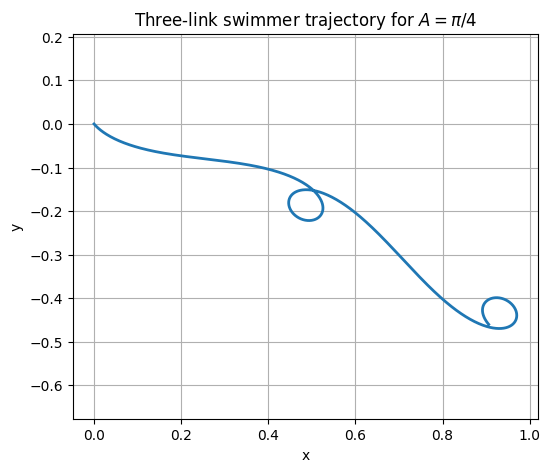

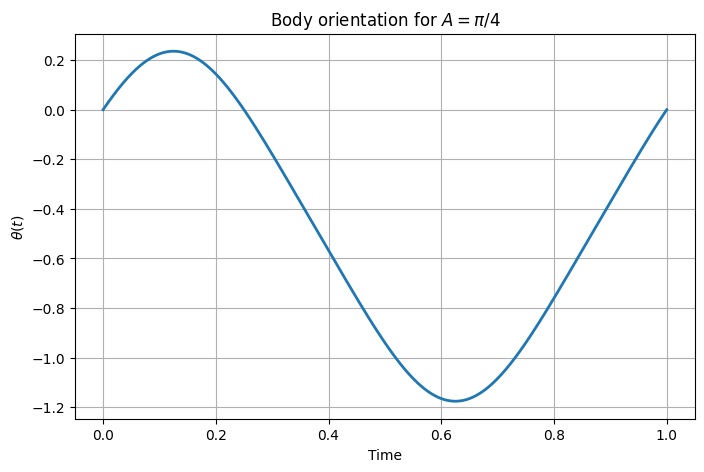

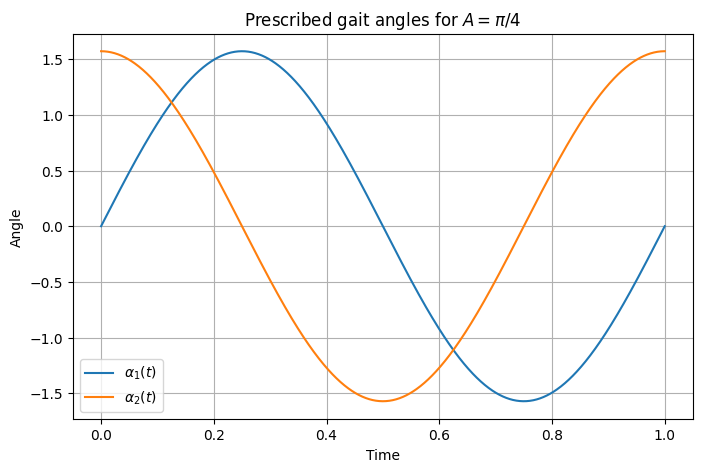

In [67]:
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Constants
A_val = np.pi / 2
phi_val = np.pi / 2
k_val = 1.0
L1_val = 1.0
Lb_val = 1.0
L2_val = 1.0

params = (A_val, phi_val, k_val, L1_val, Lb_val, L2_val)

# Initial condition [x, y, theta]
z0 = np.array([
    0.0,
    0.0,
    0.0
], dtype=float)

# One gait cycle because alpha = sin(2*pi*t)
t_span = (0.0, 1.0)
t_eval = np.linspace(0.0, 1.0, 1000)

sol = solve_ivp(
    fun=lambda t_num, z: swimmer_dynamics(t_num, z, params),
    t_span=t_span,
    y0=z0,
    t_eval=t_eval,
    rtol=1e-8,
    atol=1e-10
)

# Recover gait angles for plotting
alpha1_sol, alpha2_sol = gait_angles(sol.t, A_val, phi_val)

# Plot swimmer trajectory
plt.figure(figsize=(6,5))
plt.plot(sol.y[0, :], sol.y[1, :], linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title(r'Three-link swimmer trajectory for $A=\pi/4$')
plt.axis('equal')
plt.grid(True)
plt.show()

# Plot theta over time
plt.figure(figsize=(8,5))
plt.plot(sol.t, sol.y[2, :], linewidth=2)
plt.xlabel('Time')
plt.ylabel(r'$\theta(t)$')
plt.title(r'Body orientation for $A=\pi/4$')
plt.grid(True)
plt.show()

# Plot prescribed shape variables
plt.figure(figsize=(8,5))
plt.plot(sol.t, alpha1_sol, label=r'$\alpha_1(t)$')
plt.plot(sol.t, alpha2_sol, label=r'$\alpha_2(t)$')
plt.xlabel('Time')
plt.ylabel('Angle')
plt.title(r'Prescribed gait angles for $A=\pi/4$')
plt.legend()
plt.grid(True)
plt.show()

## Part 8

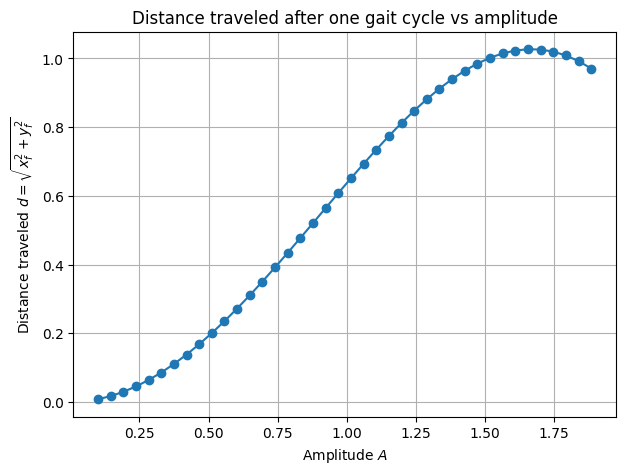

Best A: 1.6561151316213278
Maximum distance: 1.02679652515557


In [65]:
# Sweep A and plot distance traveled over one gait cycle
phi_val = np.pi / 2
k_val = 1.0
L1_val = 1.0
Lb_val = 1.0
L2_val = 1.0

# A ranges from 0.1 to 1.2*pi/2
A_vals = np.linspace(0.1, 1.2*np.pi/2, 40)

distances = []

t_span = (0.0, 1.0)  # one gait cycle
t_eval = np.linspace(0.0, 1.0, 1000)

for A_val in A_vals:

    params = (A_val, phi_val, k_val, L1_val, Lb_val, L2_val)

    # Initial condition [x, y, theta]
    z0 = np.array([0.0, 0.0, 0.0], dtype=float)

    sol = solve_ivp(
        fun=lambda t_num, z: swimmer_dynamics(t_num, z, params),
        t_span=t_span,
        y0=z0,
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10
    )

    x_final = sol.y[0, -1]
    y_final = sol.y[1, -1]

    distance = np.sqrt(x_final**2 + y_final**2)
    distances.append(distance)

distances = np.array(distances)

# Plot distance vs A
plt.figure(figsize=(7,5))
plt.plot(A_vals, distances, marker='o')
plt.xlabel(r'Amplitude $A$')
plt.ylabel(r'Distance traveled $d=\sqrt{x_f^2+y_f^2}$')
plt.title('Distance traveled after one gait cycle vs amplitude')
plt.grid(True)
plt.show()

# Print the best amplitude
best_index = np.argmax(distances)
print("Best A:", A_vals[best_index])
print("Maximum distance:", distances[best_index])